# Классификация ботов — решение



In [79]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from metric import precision_at_recall   # официальная реализация, ей же считает автопроверка
import matplotlib.pyplot as plt

train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean().round(4))
train.head()

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [80]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


## Осмотреться

Прежде чем считать агрегаты, стоит посмотреть на данные: какие типы событий бывают, что
лежит в `platform` и `user_agent`, где пропуски, всё ли уникально.

In [81]:
print(events.event_name.value_counts(), '\n')
print(events.platform.value_counts(), '\n')
print('пропуски по колонкам:')
print(events.isna().mean().round(3))

event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64 

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64 

пропуски по колонкам:
cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64


## Окно наблюдения

Признаки считаем только по событиям внутри окна: `window_start_ts <= event_ts < window_end_ts`.
Это требование из условия, а не рекомендация.

In [82]:
def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print(len(ev_tr), len(ev_te))

198436 89690


In [83]:
def make_features(ev, meta, event_names):
    e = ev.sort_values(['cookie_id', 'event_ts']).copy()
    e['gap_s'] = (
        e.groupby('cookie_id')
         .event_ts.diff()
         .dt.total_seconds()
    )
    e['minute'] = e.event_ts.dt.floor('min')
    e['hour'] = e.event_ts.dt.floor('h')

    for h in [1, 3, 6, 12]:
        e[f'last_{h}h'] = (
            e.event_ts >= e.window_end_ts - pd.Timedelta(hours=h)
        ).astype(int)

    g = e.groupby('cookie_id')

    f = pd.DataFrame({
        'n_events': g.size(),

        'item_nunique': g.item_id.nunique(),
        'category_nunique': g.item_category.nunique(),
        'location_nunique': g.item_location.nunique(),
        'seller_type_nunique': g.seller_type.nunique(),
        'query_nunique': g.search_query.nunique(),

        'gap_mean_s': g.gap_s.mean(),
        'gap_median_s': g.gap_s.median(),
        'gap_std_s': g.gap_s.std(),
        'gap_max_s': g.gap_s.max(),

        'active_minutes': g.minute.nunique(),
        'active_hours': g.hour.nunique(),
    })

    counts = pd.crosstab(e.cookie_id, e.event_name)

    counts = counts.reindex(
        columns=event_names,
        fill_value=0
    )

    counts.columns = [
        f'count_{name}'
        for name in counts.columns
    ]

    f = f.join(counts)

    for name in event_names:
        f[f'share_{name}'] = (
            f[f'count_{name}'] / f['n_events']
        )

    for t in [1, 2, 5, 10, 30, 60]:

        short_gap = (
            ((e.gap_s <= t) & e.gap_s.notna())
            .groupby(e.cookie_id)
            .mean()
        )

        f[f'gap_le_{t}s_share'] = short_gap

    f['max_events_per_minute'] = (
        e.groupby(['cookie_id', 'minute'])
         .size()
         .groupby(level=0)
         .max()
    )

    f['item_per_event'] = (
        f.item_nunique / f.n_events
    )

    f['category_per_event'] = (
        f.category_nunique / f.n_events
    )

    f['query_per_event'] = (
        f.query_nunique / f.n_events
    )

    for h in [1, 3, 6, 12]:
        f[f'events_last_{h}h'] = (
            g[f'last_{h}h'].sum()
        )
        f[f'share_last_{h}h'] = (
            f[f'events_last_{h}h']
            / f.n_events
        )

    pages = (
        e.assign(
            search_page=pd.to_numeric(
                e.search_page,
                errors='coerce'
            )
        )
        .groupby('cookie_id')
        .search_page
        .agg(
            search_page_mean='mean',
            search_page_max='max'
        )
    )

    f = f.join(pages)

    f = meta[['cookie_id']].merge(
        f.reset_index(),
        on='cookie_id',
        how='left'
    )

    zero_cols = [
        c for c in f.columns
        if c.startswith('count_')
        or c.startswith('share_')
    ]

    zero_cols += [
        'n_events',
        'item_nunique',
        'category_nunique',
        'location_nunique',
        'seller_type_nunique',
        'query_nunique',
        'active_minutes',
        'active_hours',
        'max_events_per_minute',
        'events_last_1h',
        'events_last_3h',
        'events_last_6h',
        'events_last_12h',
    ]

    f[zero_cols] = f[zero_cols].fillna(0)

    f = (
        f.replace([np.inf, -np.inf], np.nan)
         .fillna(-1)
    )

    return f

In [84]:
event_names = sorted(
    ev_tr.event_name.unique()
)

Xtr2 = make_features(
    ev_tr,
    train,
    event_names
)

Xte2 = make_features(
    ev_te,
    test,
    event_names
)

cols2 = [
    c for c in Xtr2.columns
    if c != 'cookie_id'
]

y = train.target.values

print('число признаков:', len(cols2))

число признаков: 50


## Простейшие признаки

Два агрегата — сколько событий и сколько разных объявлений. Этого заведомо мало.

In [85]:
def basic_features(ev, meta):
    g = ev.groupby('cookie_id')
    f = pd.DataFrame({
        'n_events': g.size(),
        'item_nunique': g.item_id.nunique(),
    })
    f = meta[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left')
    return f.fillna(0)

Xtr = basic_features(ev_tr, train)
Xte = basic_features(ev_te, test)
ytr = train.target.values
Xtr.head()

,cookie_id,n_events,item_nunique
0,ck_54a059eb7d3ea68b,7,4
1,ck_7e4de46eeab82974,41,19
2,ck_9320229ef6304522,36,19
3,ck_30ccd25bc1714ed9,21,10
4,ck_a77c5f05948cdeef,29,16


## Валидация

Тест лежит **позже** трейна по времени, поэтому и валидацию честно делать по времени, а не
случайным сплитом.

Метрику берём из `metric.py` — это ровно тот код, которым считает проверяющая система.
Своя реализация почти наверняка разойдётся с официальной на одинаковых `score`:
их нельзя разделять, группа равных значений отмечается целиком.

In [86]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = ['n_events', 'item_nunique']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr.loc[~is_valid, cols], ytr[~is_valid])
p_va = model.predict_proba(Xtr.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr[is_valid], p_va), 4))
print('доля ботов (это уровень константы):', round(ytr[is_valid].mean(), 4))

P@R0.7 на валидации: 0.1025
доля ботов (это уровень константы): 0.082


## Сабмит

In [87]:
model.fit(Xtr[cols], ytr)
sub = pd.DataFrame({
    'cookie_id': Xte.cookie_id,
    'score': model.predict_proba(Xte[cols])[:, 1],
})
assert len(sub) == len(test) and sub.score.between(0, 1).all()
sub.to_csv('submission.csv', index=False)
sub.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.052951
1,ck_a76ee3b3e3e522fd,0.058161
2,ck_94c9a4d382689e82,0.037449
3,ck_8eaf9509ad9462a0,0.058161
4,ck_9a88a5a989cb5bc6,0.034818


## Копаем дальше

Подумали над вопросами:

* чем поток событий робота отличается от потока событий человека, если смотреть не на
  количество, а на **моменты времени**; - будем смотреть на характер действий и как они размазаны по времени, чтобы оценить поведение
* что полезного лежит в строке `user_agent` и почему её нельзя брать как есть; - из юзер-агента можно узнать тех информацию об устройстве и браузере, чтобы не переобучиться из-за уникальных значений в сырой строке нужно будет ее как-то преобразовать
* насколько разнообразно то, что смотрит кука: объявления, категории, запросы, страницы выдачи; - оценим поведение куки и будем искать закономерности
* всё ли в порядке с самим файлом событий — порядок строк, дубликаты, пропуски; - есть все вышеперечисленное, надо понять причину
* какие признаки бесполезны, потому что описывают технические характеристики, а не поведение. - версия браузера, например

## Events

Начнем подключать другие признаки, так как по количеству событий сложно сказать что-то однозначное

Сначала посмотрим на данные, затем будем добавлять признаки и сравнивать качество на той же временной валидации

In [88]:
fit_ids = train.loc[~is_valid, 'cookie_id']
ev_fit = ev_tr.loc[ev_tr.cookie_id.isin(fit_ids)].copy()

display(ev_fit.event_name.value_counts().to_frame('кол-во событий'))
display(ev_fit.isna().mean().sort_values(ascending=False).to_frame('доля пропусков'))
print('дубликатов', ev_fit.duplicated().sum())

event_names = sorted(ev_fit.event_name.dropna().unique())

,кол-во событий
event_name,
item_view,60841
search_results_view,50564
photo_swipe,18822
favorite_add,9824
seller_page_view,8734
contact_phone_show,5762
login,3217
contact_chat_open,3090
contact_message_sent,1598


,доля пропусков
search_query,0.688745
search_page,0.688745
pointer_x,0.662799
pointer_y,0.662799
seller_type,0.392220
item_id,0.331058
item_category,0.079150
item_location,0.049608
platform,0.000000
user_agent,0.000000


дубликатов 2409


In [89]:
def event_features(ev, meta, event_names):
    g = ev.groupby('cookie_id')
    f = pd.DataFrame({
        'n_events': g.size(),
        'item_nunique': g.item_id.nunique(),
        'category_nunique': g.item_category.nunique(),
        'location_nunique': g.item_location.nunique(),
        'query_nunique': g.search_query.nunique(),
    })

    counts = pd.crosstab(ev.cookie_id, ev.event_name)
    counts = counts.reindex(columns=event_names, fill_value=0)
    count_cols = ['count_' + name for name in event_names]
    counts.columns = count_cols
    f = f.join(counts)
    f[count_cols] = f[count_cols].fillna(0)

    for name in event_names:
        f['share_' + name] = f['count_' + name] / f['n_events']

    pages = ev.assign(search_page=pd.to_numeric(ev.search_page, errors='coerce'))
    page_stats = pages.groupby('cookie_id').search_page.agg(
        search_page_mean='mean', search_page_max='max'
    )
    f = f.join(page_stats)

    f = meta[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left')
    zero_cols = [
        'n_events', 'item_nunique', 'category_nunique',
        'location_nunique', 'query_nunique',
    ] + count_cols + ['share_' + name for name in event_names]
    f[zero_cols] = f[zero_cols].fillna(0)
    f['cookie_age_h'] = (
        (meta.window_end_ts - meta.cookie_created_at).dt.total_seconds() / 3600
    ).to_numpy()
    return f

In [90]:
Xtr_events = event_features(ev_tr, train, event_names)
event_cols = [c for c in Xtr_events.columns if c != 'cookie_id']

assert Xtr_events.cookie_id.tolist() == train.cookie_id.tolist()

print('теперь признаков:', len(event_cols))
display(Xtr_events.head())

look = Xtr_events.loc[~is_valid, [
    'n_events', 'item_nunique', 'category_nunique', 'query_nunique', 'cookie_age_h'
]].copy()
look['target'] = ytr[~is_valid]
display(look.groupby('target').median())

теперь признаков: 26


,cookie_id,n_events,item_nunique,category_nunique,location_nunique,query_nunique,count_contact_chat_open,count_contact_message_sent,count_contact_phone_show,count_favorite_add,...,share_contact_phone_show,share_favorite_add,share_item_view,share_login,share_photo_swipe,share_search_results_view,share_seller_page_view,search_page_mean,search_page_max,cookie_age_h
0,ck_54a059eb7d3ea68b,7,4,3,5,3,0,0,0,0,...,0.000000,0.000000,0.428571,0.000000,0.142857,0.428571,0.000000,3.000000,6.0,3278.488611
1,ck_7e4de46eeab82974,41,19,1,12,5,0,0,1,1,...,0.024390,0.024390,0.536585,0.024390,0.097561,0.195122,0.097561,3.625000,8.0,4693.826667
2,ck_9320229ef6304522,36,19,7,9,10,1,1,2,3,...,0.055556,0.083333,0.194444,0.083333,0.083333,0.361111,0.083333,3.538462,10.0,815.866111
3,ck_30ccd25bc1714ed9,21,10,1,4,3,1,0,1,0,...,0.047619,0.000000,0.666667,0.000000,0.000000,0.142857,0.095238,1.666667,2.0,37.122222
4,ck_a77c5f05948cdeef,29,16,4,6,6,0,0,1,2,...,0.034483,0.068966,0.448276,0.000000,0.137931,0.206897,0.103448,2.833333,7.0,2300.090278


,n_events,item_nunique,category_nunique,query_nunique,cookie_age_h
target,,,,,
0,12.0,6.0,2.0,3.0,1518.963333
1,20.0,11.0,2.0,4.0,540.195000


## График разделения по классам

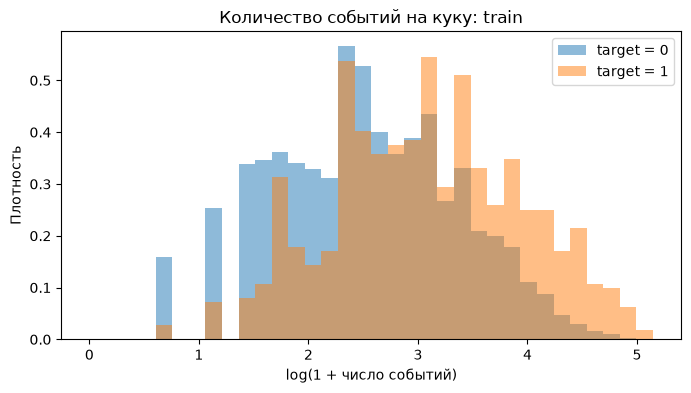

In [91]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, np.log1p(look.n_events.max()) + 0.01, 35)

for target in [0, 1]:
    values = np.log1p(look.loc[look.target == target, 'n_events'])
    ax.hist(values, bins=bins, density=True, alpha=0.5, label=f'target = {target}')

ax.set(xlabel='log(1 + число событий)', ylabel='Плотность',
       title='Количество событий на куку: train')
ax.legend()
plt.show()

## Catboost

Возьмем вторую модель для сравнения. Обучим ее на 2 признаках из бейзлайна и на расширенном наборе признаков: если улучшения есть, значит и признаки из events способствуют улучшению качества

In [92]:
from catboost import CatBoostClassifier
from sklearn.base import clone
from IPython.display import display
import matplotlib.pyplot as plt

base_cols = ['n_events', 'item_nunique']

rf_score = precision_at_recall(ytr[is_valid], p_va)
rf_model = model

assert train.cookie_id.is_unique and test.cookie_id.is_unique
assert train.cookie_id.notna().all() and test.cookie_id.notna().all()
assert not train.cookie_id.isin(test.cookie_id).any()
assert set(np.unique(ytr[~is_valid])) == {0, 1}
assert set(np.unique(ytr[is_valid])) == {0, 1}

cat_params = dict(
    iterations=600,
    depth=5,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=0,
    thread_count=4,
    verbose=False,
    allow_writing_files=False,
)

cat_basic = CatBoostClassifier(**cat_params)
cat_basic.fit(Xtr.loc[~is_valid, base_cols], ytr[~is_valid])
p_basic = cat_basic.predict_proba(Xtr.loc[is_valid, base_cols])[:, 1]
cat_basic_score = precision_at_recall(ytr[is_valid], p_basic)

print('Random Forest, 2 признака:', round(rf_score, 4))
print('CatBoost, 2 признака:', round(cat_basic_score, 4))

Random Forest, 2 признака: 0.1025
CatBoost, 2 признака: 0.1157


In [93]:
cat_events = CatBoostClassifier(**cat_params)
cat_events.fit(Xtr_events.loc[~is_valid, event_cols], ytr[~is_valid])
p_events = cat_events.predict_proba(Xtr_events.loc[is_valid, event_cols])[:, 1]
cat_events_score = precision_at_recall(ytr[is_valid], p_events)

print('CatBoost, 2 признака:', round(cat_basic_score, 4))
print('CatBoost, признаки действий:', round(cat_events_score, 4))

CatBoost, 2 признака: 0.1157
CatBoost, признаки действий: 0.3128


## Разберемся с "моментами времени"

По количеству событий сложно сказать что-то про активность этих событий => посортируем события каждой куки по времени и посчитаем интервалы между соседними действиями

In [94]:
def time_features(ev, meta):
    e = ev.sort_values(['cookie_id', 'event_ts']).copy()
    e['gap_s'] = e.groupby('cookie_id').event_ts.diff().dt.total_seconds()
    e['zero_gap'] = e.gap_s.eq(0).astype(float).where(e.gap_s.notna())
    e['minute'] = e.event_ts.dt.floor('min')
    e['hour'] = e.event_ts.dt.floor('h')
    e['last_hour'] = (
        e.event_ts >= e.window_end_ts - pd.Timedelta(hours=1)
    ).astype(int)

    f = e.groupby('cookie_id').agg(
        gap_mean_s=('gap_s', 'mean'),
        gap_median_s=('gap_s', 'median'),
        gap_std_s=('gap_s', 'std'),
        gap_max_s=('gap_s', 'max'),
        zero_gap_share=('zero_gap', 'mean'),
        active_minutes=('minute', 'nunique'),
        active_hours=('hour', 'nunique'),
        events_last_hour=('last_hour', 'sum'),
        first_event=('event_ts', 'min'),
        last_event=('event_ts', 'max'),
    )

    f = meta[['cookie_id', 'window_end_ts']].merge(
        f.reset_index(), on='cookie_id', how='left'
    )
    f['activity_h'] = (f.last_event - f.first_event).dt.total_seconds() / 3600
    f['last_event_ago_h'] = (f.window_end_ts - f.last_event).dt.total_seconds() / 3600
    zero_cols = ['active_minutes', 'active_hours', 'events_last_hour']
    f[zero_cols] = f[zero_cols].fillna(0)
    return f.drop(columns=['window_end_ts', 'first_event', 'last_event'])

In [95]:
Xtr_full = Xtr_events.merge(
    time_features(ev_tr, train), on='cookie_id', how='left'
)
full_cols = [c for c in Xtr_full.columns if c != 'cookie_id']

assert Xtr_full.cookie_id.tolist() == train.cookie_id.tolist()

look_time = Xtr_full.loc[~is_valid, [
    'gap_median_s', 'gap_std_s', 'zero_gap_share',
    'active_hours', 'activity_h', 'events_last_hour'
]].copy()
look_time['target'] = ytr[~is_valid]
display(look_time.groupby('target').median())

,gap_median_s,gap_std_s,zero_gap_share,active_hours,activity_h,events_last_hour
target,,,,,,
0,59.50,1732.975610,0.0,3.0,2.296389,0.0
1,24.25,1354.439413,0.0,3.0,2.535833,0.0


Добавим временные признаки к признакам действий и снова считаем ту же метрику. Так можно отдельно проверить дали ли интервалы между событиями дополнительную информацию

In [96]:
cat_time = CatBoostClassifier(**cat_params)
cat_time.fit(Xtr_full.loc[~is_valid, full_cols], ytr[~is_valid])
p_time = cat_time.predict_proba(Xtr_full.loc[is_valid, full_cols])[:, 1]
cat_time_score = precision_at_recall(ytr[is_valid], p_time)

print('CatBoost, признаки действий:        ', round(cat_events_score, 4))
print('CatBoost, признаки действий + время:', round(cat_time_score, 4))

CatBoost, признаки действий:         0.3128
CatBoost, признаки действий + время: 0.5185


## Сравнение

Сравним все построенные варианты на одной и той же временной валидации

Переход от Random Forest к CatBoost на тех же двух признаках дал небольшой прирост: 
P@R0.7 вырос с 0.1025 до 0.1157

Признаки действий из events повысили метрику до 0.3128, а добавление временных характеристик до 0.5185

In [97]:
variants = {
    'RF: 2 признака': (rf_model, base_cols, rf_score),
    'CatBoost: 2 признака': (cat_basic, base_cols, cat_basic_score),
    'CatBoost: действия': (cat_events, event_cols, cat_events_score),
    'CatBoost: действия + время': (cat_time, full_cols, cat_time_score),
}

results = pd.DataFrame([
    {'вариант': name, 'признаков': len(columns), 'P@R0.7': score}
    for name, (_, columns, score) in variants.items()
]).set_index('вариант')

display(results.round(4))

,признаков,P@R0.7
вариант,,
RF: 2 признака,2,0.1025
CatBoost: 2 признака,2,0.1157
CatBoost: действия,26,0.3128
CatBoost: действия + время,36,0.5185


## Важность признаков

Выведем наиболее важные признаки, чтобы понять какие характеристики поведения дают модели больше информации при классификации

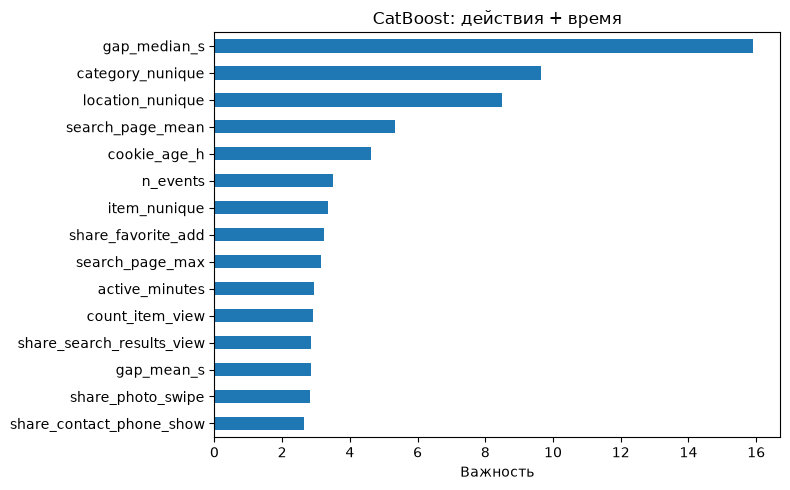

In [98]:
importance = pd.Series(cat_time.feature_importances_, index=full_cols)
top = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
top.plot.barh(ax=ax)
ax.set(xlabel='Важность', title='CatBoost: действия + время')
plt.tight_layout()
plt.show()

## Возвращаемся к events

Кроме признаков действий и времени добавим ещё несколько простых характеристик:
* долю очень коротких интервалов между событиями
* макс число событий/мин
* активность за последние 1, 3, 6 и 12 часов окна
* относительное разнообразие объявлений, категорий и запросов
* число платформ и предобработанный `user_agent`
* курсор `pointer_x` и `pointer_y`
* среднюю и максимальную страницу поиска

In [99]:
def feature_engineering(ev, meta, event_names):
    e = ev.sort_values(['cookie_id', 'event_ts']).copy()

    e['gap_s'] = (
        e.groupby('cookie_id')
         .event_ts.diff()
         .dt.total_seconds()
    )

    e['minute'] = e.event_ts.dt.floor('min')
    e['hour'] = e.event_ts.dt.floor('h')

    for h in [1, 3, 6, 12]:
        e[f'last_{h}h'] = (
            e.event_ts >= e.window_end_ts - pd.Timedelta(hours=h)
        ).astype(int)

    g = e.groupby('cookie_id')

    f = pd.DataFrame({
        'n_events': g.size(),

        # разнообразие
        'item_nunique': g.item_id.nunique(),
        'category_nunique': g.item_category.nunique(),
        'location_nunique': g.item_location.nunique(),
        'seller_type_nunique': g.seller_type.nunique(),
        'query_nunique': g.search_query.nunique(),
        'platform_nunique': g.platform.nunique(),
        'user_agent_nunique': g.user_agent.nunique(),

        # интервалы
        'gap_mean_s': g.gap_s.mean(),
        'gap_median_s': g.gap_s.median(),
        'gap_std_s': g.gap_s.std(),
        'gap_max_s': g.gap_s.max(),
        'gap_q10_s': g.gap_s.quantile(0.10),
        'gap_q90_s': g.gap_s.quantile(0.90),

        # активность
        'active_minutes': g.minute.nunique(),
        'active_hours': g.hour.nunique(),
    })

    counts = pd.crosstab(e.cookie_id, e.event_name)
    counts = counts.reindex(columns=event_names, fill_value=0)
    counts.columns = [f'count_{name}' for name in counts.columns]
    f = f.join(counts)

    for name in event_names:
        f[f'share_{name}'] = (
            f[f'count_{name}'] / f['n_events']
        )

    for t in [1, 2, 5, 10, 30, 60]:
        short_gap = (
            ((e.gap_s <= t) & e.gap_s.notna())
            .groupby(e.cookie_id)
            .mean()
        )
        f[f'gap_le_{t}s_share'] = short_gap

    f['max_events_per_minute'] = (
        e.groupby(['cookie_id', 'minute'])
         .size()
         .groupby(level=0)
         .max()
    )

    f['item_per_event'] = f.item_nunique / f.n_events
    f['category_per_event'] = f.category_nunique / f.n_events
    f['query_per_event'] = f.query_nunique / f.n_events

    for h in [1, 3, 6, 12]:
        f[f'events_last_{h}h'] = g[f'last_{h}h'].sum()
        f[f'share_last_{h}h'] = (
            f[f'events_last_{h}h'] / f.n_events
        )

    pages = (
        e.assign(
            search_page=pd.to_numeric(
                e.search_page,
                errors='coerce'
            )
        )
        .groupby('cookie_id')
        .search_page
        .agg(
            search_page_mean='mean',
            search_page_max='max'
        )
    )
    f = f.join(pages)

    pointer = e.groupby('cookie_id').agg(
        pointer_x_std=('pointer_x', 'std'),
        pointer_y_std=('pointer_y', 'std'),
        pointer_x_nunique=('pointer_x', 'nunique'),
        pointer_y_nunique=('pointer_y', 'nunique'),
        pointer_x_count=('pointer_x', 'count'),
    )
    f = f.join(pointer)
    f['pointer_share'] = f.pointer_x_count / f.n_events

    age = (
        (meta.window_end_ts - meta.cookie_created_at)
        .dt.total_seconds() / 3600
    )

    f = meta[['cookie_id']].merge(
        f.reset_index(),
        on='cookie_id',
        how='left'
    )
    f['cookie_age_h'] = age.to_numpy()

    zero_cols = [
        c for c in f.columns
        if c.startswith('count_')
        or c.startswith('share_')
    ]

    zero_cols += [
        'n_events',
        'item_nunique',
        'category_nunique',
        'location_nunique',
        'seller_type_nunique',
        'query_nunique',
        'platform_nunique',
        'user_agent_nunique',
        'active_minutes',
        'active_hours',
        'max_events_per_minute',
        'events_last_1h',
        'events_last_3h',
        'events_last_6h',
        'events_last_12h',
        'pointer_x_nunique',
        'pointer_y_nunique',
        'pointer_x_count',
    ]

    zero_cols = [c for c in zero_cols if c in f.columns]
    f[zero_cols] = f[zero_cols].fillna(0)

    f = (
        f.replace([np.inf, -np.inf], np.nan)
         .fillna(-1)
    )

    return f

In [100]:
event_names_final = sorted(ev_tr.event_name.dropna().unique())

Xtr_final = feature_engineering(
    ev_tr,
    train,
    event_names_final
)

Xte_final = feature_engineering(
    ev_te,
    test,
    event_names_final
)

final_cols = [
    c for c in Xtr_final.columns
    if c != 'cookie_id'
]

assert Xtr_final.cookie_id.tolist() == train.cookie_id.tolist()
assert Xte_final.cookie_id.tolist() == test.cookie_id.tolist()
assert Xtr_final.columns.tolist() == Xte_final.columns.tolist()

print('Итоговое число признаков:', len(final_cols))
display(Xtr_final.head())

Итоговое число признаков: 61


,cookie_id,n_events,item_nunique,category_nunique,location_nunique,seller_type_nunique,query_nunique,platform_nunique,user_agent_nunique,gap_mean_s,...,share_last_12h,search_page_mean,search_page_max,pointer_x_std,pointer_y_std,pointer_x_nunique,pointer_y_nunique,pointer_x_count,pointer_share,cookie_age_h
0,ck_54a059eb7d3ea68b,7,4,3,5,2,3,3,1,27.833333,...,0.000000,3.000000,6.0,-1.000000,-1.000000,0,0,0,0.000000,3278.488611
1,ck_7e4de46eeab82974,41,19,1,12,2,5,4,1,986.900000,...,0.682927,3.625000,8.0,509.231969,272.953569,36,38,38,0.926829,4693.826667
2,ck_9320229ef6304522,36,19,7,9,2,10,4,1,1042.600000,...,0.000000,3.538462,10.0,602.124295,312.027426,35,35,35,0.972222,815.866111
3,ck_30ccd25bc1714ed9,21,10,1,4,2,3,4,1,861.050000,...,0.000000,1.666667,2.0,-1.000000,-1.000000,0,0,0,0.000000,37.122222
4,ck_a77c5f05948cdeef,29,16,4,6,2,6,4,1,682.071429,...,0.689655,2.833333,7.0,450.787816,297.263925,27,27,28,0.965517,2300.090278


## Подбор гиперпараметров

После формирования итогового набора признаков подберем параметры CatBoost с помощью GridSearchCV

Сохраняем временное разбиение: модель обучается на более ранних данных и проверяется на более поздних. В качестве скоринга используется метрика Precision@Recall >= 0.7

In [101]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin

class CatBoostSK(ClassifierMixin, BaseEstimator):
    def __init__(
        self,
        iterations=700,
        depth=5,
        learning_rate=0.05,
        l2_leaf_reg=3,
        random_seed=0
    ):
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.l2_leaf_reg = l2_leaf_reg
        self.random_seed = random_seed

    def fit(self, X, y):
        self.model_ = CatBoostClassifier(
            iterations=self.iterations,
            depth=self.depth,
            learning_rate=self.learning_rate,
            l2_leaf_reg=self.l2_leaf_reg,
            loss_function='Logloss',
            random_seed=self.random_seed,
            verbose=False,
            allow_writing_files=False,
            thread_count=4
        )
        self.model_.fit(X, y)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


def catboost_score(estimator, X, y):
    pred = estimator.predict_proba(X)[:, 1]
    return precision_at_recall(y, pred)


train_idx = np.where(~is_valid)[0]
valid_idx = np.where(is_valid)[0]

time_cv = [
    (train_idx, valid_idx)
]

param_grid = {
    'depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.08],
    'l2_leaf_reg': [3, 5, 8],
}

grid_final = GridSearchCV(
    estimator=CatBoostSK(iterations=700),
    param_grid=param_grid,
    scoring=catboost_score,
    cv=time_cv,
    refit=True,
    n_jobs=1,
    verbose=1
)

grid_final.fit(
    Xtr_final[final_cols],
    ytr
)

print(
    'Лучший P@R0.7:',
    round(grid_final.best_score_, 4)
)

print(
    'Лучшие параметры:',
    grid_final.best_params_
)


Fitting 1 folds for each of 27 candidates, totalling 27 fits
Лучший P@R0.7: 0.7832
Лучшие параметры: {'depth': 4, 'l2_leaf_reg': 5, 'learning_rate': 0.03}


In [102]:
grid_results = pd.DataFrame(
    grid_final.cv_results_
)

grid_results[
    [
        'param_depth',
        'param_learning_rate',
        'param_l2_leaf_reg',
        'mean_test_score'
    ]
].sort_values(
    'mean_test_score',
    ascending=False
).head(10)


,param_depth,param_learning_rate,param_l2_leaf_reg,mean_test_score
3,4,0.03,5,0.783217
9,5,0.03,3,0.777778
15,5,0.03,8,0.772414
12,5,0.03,5,0.768707
0,4,0.03,3,0.767123
7,4,0.05,8,0.767123
1,4,0.05,3,0.763514
13,5,0.05,5,0.763514
25,6,0.05,8,0.761905
6,4,0.03,8,0.761905


## Финальная модель

In [103]:
best_model = grid_final.best_estimator_

print('Лучшие параметры:', grid_final.best_params_)
print('P@R0.7:', round(grid_final.best_score_, 4))

test_score = best_model.predict_proba(
    Xte_final[final_cols]
)[:, 1]

submission = pd.DataFrame({
    'cookie_id': test.cookie_id,
    'score': test_score,
})

assert len(submission) == len(test)
assert submission.score.between(0, 1).all()

submission.to_csv(
    'submission.csv',
    index=False
)

submission.head()


Лучшие параметры: {'depth': 4, 'l2_leaf_reg': 5, 'learning_rate': 0.03}
P@R0.7: 0.7832


,cookie_id,score
0,ck_315fb710a0e371e7,0.000753
1,ck_a76ee3b3e3e522fd,0.074817
2,ck_94c9a4d382689e82,0.033678
3,ck_8eaf9509ad9462a0,0.001634
4,ck_9a88a5a989cb5bc6,0.017694
